# 5. Training the MACE Potential

We have our MACE model. Now we need to train it to predict quantum mechanical energies and forces. 

In this notebook, we'll construct a small synthetic dataset by perturbing a Benzene molecule, and we'll use our joint Energy-Force loss function to optimize the network weights.

In [1]:
import os
import sys
import torch
import copy
import numpy as np
import matplotlib.pyplot as plt
from ase.build import molecule
from torch_geometric.loader import DataLoader

sys.path.append(os.path.abspath('..'))
from src.data import atoms_to_pyg_data
from src.model import MACE
from src.training import train_one_epoch, evaluate
from src.utils import set_seed, get_default_device

set_seed(42)
device = get_default_device()
print(f"Using device: {device}")

Using device: cpu


### Creating a Synthetic Dataset

To avoid downloading a massive dataset like MD17, we'll create 50 slightly perturbed versions of Benzene. We will assign a dummy energy and dummy forces (based simply on a harmonic spring to the equilibrium position) just to prove the network can learn.

In [2]:
base_atoms = molecule('C6H6')
base_pos = base_atoms.get_positions()
dataset = []

for i in range(50):
    atoms = copy.deepcopy(base_atoms)
    
    # Add random noise to positions
    noise = np.random.normal(0, 0.05, base_pos.shape)
    atoms.set_positions(base_pos + noise)
    
    # Synthetic Energy: Harmonic potential E = 0.5 * k * sum(dx^2)
    # Synthetic Forces: F = -k * dx
    k = 10.0
    energy = 0.5 * k * np.sum(noise**2)
    forces = -k * noise
    
    atoms.info['energy'] = energy
    # We manually add forces to the Atoms object (usually an ASE Calculator does this)
    # For data.py to pick it up, we mock get_forces()
    atoms.get_forces = lambda f=forces: f
    
    data = atoms_to_pyg_data(atoms, cutoff=4.0)
    dataset.append(data)

# Split into train/val
train_loader = DataLoader(dataset[:40], batch_size=4, shuffle=True)
val_loader = DataLoader(dataset[40:], batch_size=4)

print(f"Created {len(dataset)} graphs.")

Created 50 graphs.


### Setting up the Model and Optimizer

In [3]:
model = MACE(num_elements=10, r_max=4.0, num_radial=4, l_max=1, num_blocks=1, node_dim=8)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

### The Training Loop

In force-matching, the loss function is $\mathcal{L} = w_E \cdot \text{MSE}(E) + w_F \cdot \text{MSE}(F)$.
Typically, $w_F$ is set very high (e.g., 100 to 1000) because there are $3N$ force components per structure, providing an incredibly rich source of gradients.

In [4]:
epochs = 20
history = {"loss": [], "val_mae_e": [], "val_mae_f": []}

for epoch in range(epochs):
    # Train
    train_metrics = train_one_epoch(
        model, train_loader, optimizer, device,
        energy_weight=1.0, force_weight=100.0
    )
    
    # Evaluate
    val_metrics = evaluate(model, val_loader, device)
    
    history["loss"].append(train_metrics['loss'])
    history["val_mae_e"].append(val_metrics['mae_e'])
    history["val_mae_f"].append(val_metrics['mae_f'])
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_metrics['loss']:.4f} | Val MAE_E: {val_metrics['mae_e']:.4f} | Val MAE_F: {val_metrics['mae_f']:.4f}")

Epoch 01 | Train Loss: 23.5615 | Val MAE_E: 0.4031 | Val MAE_F: 0.3580


Epoch 02 | Train Loss: 19.0013 | Val MAE_E: 0.4774 | Val MAE_F: 0.3283


Epoch 03 | Train Loss: 18.0432 | Val MAE_E: 0.0911 | Val MAE_F: 0.3321


Epoch 04 | Train Loss: 16.6227 | Val MAE_E: 0.2569 | Val MAE_F: 0.3203


Epoch 05 | Train Loss: 15.1737 | Val MAE_E: 0.2521 | Val MAE_F: 0.3042


...

Epoch 16 | Train Loss: 10.8247 | Val MAE_E: 0.3561 | Val MAE_F: 0.2651


Epoch 17 | Train Loss: 10.5153 | Val MAE_E: 0.1214 | Val MAE_F: 0.2675


Epoch 18 | Train Loss: 10.2715 | Val MAE_E: 0.3867 | Val MAE_F: 0.2615


Epoch 19 | Train Loss: 10.0995 | Val MAE_E: 0.1729 | Val MAE_F: 0.2596


Epoch 20 | Train Loss: 9.9461 | Val MAE_E: 0.3315 | Val MAE_F: 0.2560


### Plotting the Learning Curves

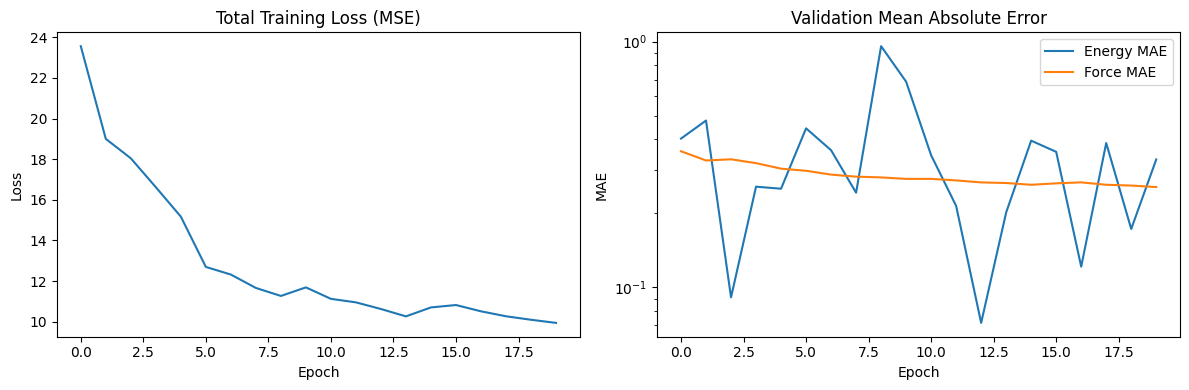

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["loss"])
ax1.set_title("Total Training Loss (MSE)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2.plot(history["val_mae_e"], label="Energy MAE")
ax2.plot(history["val_mae_f"], label="Force MAE")
ax2.set_title("Validation Mean Absolute Error")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE")
ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
plt.show()